# M5A6 - Detecção de Faixas para Veículos Autônomos

> **Resumo:** Projeto de **segmentação semântica** para carro autônomo: classificar cada pixel como "faixa/pista" ou "fundo". Refinamos uma **FCN-ResNet101** no dataset BDD100k e geramos um *overlay* da máscara sobre a imagem real.

> 📝 **Clássico vs moderno:** antes usava-se Transformada de Hough + Canny (bordas) + filtros de cor pra ajustar retas na pista; hoje redes de segmentação (FCN, UNet) classificam pixel a pixel e aguentam chuva, desgaste e oclusão muito melhor.

> ⚠️ **GPU recomendada** (Ambiente de execução → Alterar o tipo → GPU T4): a FCN-ResNet101 é pesada para treinar/inferir em CPU.

Na prática de hoje vamos refinar um modelo para a tarefa de detecção de faixas e pistas para veículos autônomos por meio de segmentação semântica.

Manter o carro corretamente posicionado na pista é uma das tarefas mais críticas para a segurança da condução autônoma. O sistema precisa identificar as faixas de rodagem sob chuva, neblina, desgaste da pintura ou iluminação variável.

Historicamente, abordagens de visão computacional clássica utilizavam a **Transformada de Hough** combinada com filtros de bordas (como Canny) e filtros de cor (isolando amarelo/branco) para ajustar linhas retas ou curvas na pista. Hoje, redes neurais profundas de **Segmentação Semântica** (como FCN ou UNet) são preferidas porque classificam cada pixel da imagem como "pista/faixa de interesse" ou "fundo", lidando com distorções e obstruções dinâmicas de forma muito mais robusta.

Esse notebook está estruturado da seguinte forma.

- Introdução
- Carregar Base de Dados
- Refinar Modelo
- Validar Modelo
- Próximos passos
- Atividades Complementares

## Introdução

Instalação para os que ainda não possuem a biblioteca instalada.

In [1]:
!pip install torch torchvision datasets tqdm ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 116.8 MB/s eta 0:00:00


Importar as bibliotecas

In [2]:
import datasets
import torch
import torchvision
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import numpy as np
import random

## Carregar Base de Dados

A primeira tarefa para refinar um modelo é criar a base de dados.

Referência: https://huggingface.co/datasets/danjacobellis/bdd100k_15frames_eomt

In [3]:
# Baixando dataset.
# Esse dataset possui apenas split de treino.
dataset = datasets.load_dataset("danjacobellis/bdd100k_15frames_eomt", split="validation")

# Split dataset.
split_ds = dataset.train_test_split(test_size=0.1, seed=42)

# Pegar splits de dados.
train_dataset = split_ds["train"]
test_dataset = split_ds["test"]

def transforms(examples):
    # Transformações das imagens.
    image_transforms = torchvision.transforms.Compose([
        torchvision.transforms.Resize(256),
        torchvision.transforms.CenterCrop(224), # Tamanho comum para modelos ImageNet
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    target_transforms = torchvision.transforms.Compose([
        torchvision.transforms.ToTensor(),
        # NEAREST: a máscara é binária. A interpolação bilinear (padrão) "borraria" as
        # faixas finas e, após o .long() no collate, elas sumiriam. NEAREST preserva os 0/1.
        torchvision.transforms.Resize(256, interpolation=torchvision.transforms.InterpolationMode.NEAREST),
        torchvision.transforms.CenterCrop(224),
    ])

    images = []
    targets = []
    
    # Obtém o tamanho do lote solicitado
    batch_size = len(examples["original_0"])
    
    for j in range(batch_size):
        # Escolhe aleatoriamente 1 frame de 0 a 13 para esta amostra
        i = random.randint(0, 13)
        
        img = examples[f"original_{i}"][j]
        lbl = examples[f"label_{i}"][j]
        
        images.append(image_transforms(img))
        # Converte o array booleano de forma estável para float32
        label_bool = (np.array(lbl) == 0).astype(np.float32)
        targets.append(target_transforms(label_bool))

    return {"image": images, "target": targets}

def collate_fn(batch):
    # Organiza o retorno do dataloader.
    images = torch.stack([item["image"] for item in batch])
    # Squeeze apenas na dimensão dos canais (dim=1) para evitar remover a dimensão de lote quando batch_size=1
    targets = torch.stack([item["target"] for item in batch]).squeeze(1).long()
    return images, targets

train_dataset =  train_dataset.with_transform(transforms)
test_dataset = test_dataset.with_transform(transforms)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/2.63k [00:00<?, ?B/s]

data/validation-00000-of-00009.parquet:   0%|          | 0.00/433M [00:00<?, ?B/s]

data/validation-00001-of-00009.parquet:   0%|          | 0.00/442M [00:00<?, ?B/s]

data/validation-00002-of-00009.parquet:   0%|          | 0.00/454M [00:00<?, ?B/s]

...

data/validation-00005-of-00009.parquet:   0%|          | 0.00/430M [00:00<?, ?B/s]

data/validation-00006-of-00009.parquet:   0%|          | 0.00/454M [00:00<?, ?B/s]

data/validation-00007-of-00009.parquet:   0%|          | 0.00/464M [00:00<?, ?B/s]

data/validation-00008-of-00009.parquet:   0%|          | 0.00/434M [00:00<?, ?B/s]

Generating validation split:   0%|          | 0/500 [00:00<?, ? examples/s]

## Refinar Modelo

Na prática de hoje iremos refinar o modelo **Fully Convolutional** disponível no torchvision.

In [4]:
# Definindo dispositivo.
device = "cuda" if torch.cuda.is_available() else "cpu"

# Carregando modelo.
model = torchvision.models.segmentation.fcn_resnet101(weights="DEFAULT")


num_classes = 2 # apenas 2 classes.
in_features = 2048 # Valor do modelo.
model.classifier = torchvision.models.segmentation.fcn.FCNHead(in_features, num_classes) # substitui a última camada do modelo.

model.to(device) # Colocando modelo no dispositivo.

# Definindo o otimizador.
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9, weight_decay=0.0001)

# class_weight = torch.tensor([0.1, 0.9]).to(device)
criterion = torch.nn.CrossEntropyLoss()

# Treinamento do modelo
model.train()
epochs = 1 # Alterar para treinar mais epocas.
for epoch in range(epochs):
    iteration = 0
    for images, targets in tqdm(train_loader):
        # Muda o dispostivo de processamento dos dados.
        images = images.to(device)
        targets = targets.to(device)

        outputs = model(images)
        loss = criterion(outputs["out"], targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        if iteration % 30 == 0:
            print(f"Total loss: {loss.item()}")
        iteration += 1

Downloading: "https://download.pytorch.org/models/fcn_resnet101_coco-7ecb50ca.pth" to /root/.cache/torch/hub/checkpoints/fcn_resnet101_coco-7ecb50ca.pth


100%|██████████| 208M/208M [00:01<00:00, 178MB/s]


  0%|          | 0/113 [00:00<?, ?it/s]

Total loss: 0.7057465314865112
Total loss: 0.484429270029068
Total loss: 0.4106004238128662
Total loss: 0.19697390496730804


## Validar Modelo

Agora vamos testar o nosso modelo.

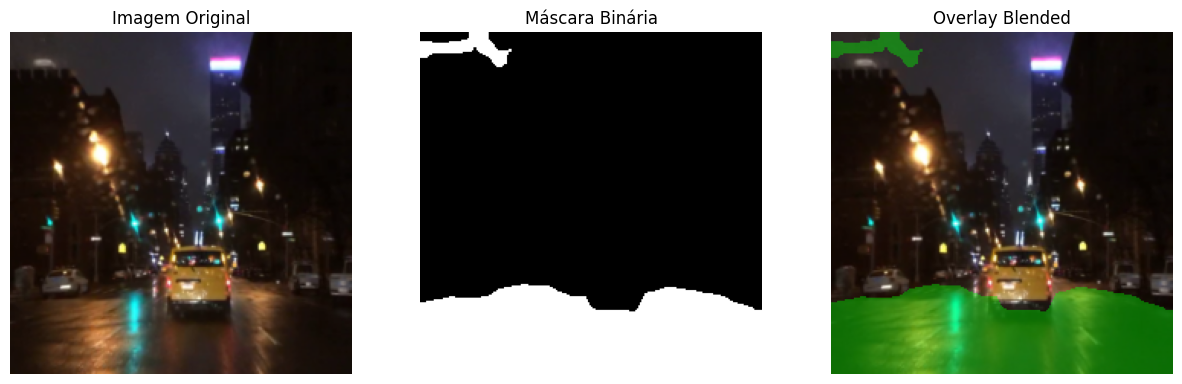

In [5]:
def decode_segmap(image, cls=1):
    r = np.zeros_like(image).astype(np.uint8)
    g = np.zeros_like(image).astype(np.uint8)
    b = np.zeros_like(image).astype(np.uint8)

    idx = image == cls
    r[idx] = 255
    g[idx] = 255
    b[idx] = 255

    rgb = np.stack([r, g, b], axis=2)
    return rgb

# Tamanho do dataset de treino.
len_test_data = len(test_dataset)

# Sortear amostra do dataset de teste.
idx = torch.randint(len_test_data, (1,))

# Modelo em modo de avaliação.
model.eval()
with torch.no_grad():
    image = torch.stack(test_dataset[idx]["image"])

    # Coloca as imagens no dispositivo e passa pelo modelo. 
    image = image.to(device)
    output = model(image)

# Selecionar a maior predição canal de classe descartando o lote com segurança (dim=1)
output = torch.argmax(output["out"], dim=1).squeeze(0).detach().cpu().numpy()

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

# Reconstruir imagem original em formato RGB desnormalizada
original_img = (image.detach().cpu()[0].permute(1, 2, 0).numpy() * std) + mean
original_img = np.clip(original_img, 0, 1)

# Gerar overlay blended com máscara verde translúcida na área predita (faixa/pista)
overlay_img = original_img.copy()
mask_indices = output == 1
overlay_img[mask_indices] = 0.6 * original_img[mask_indices] + 0.4 * np.array([0.0, 1.0, 0.0])

# Criar visualização premium com 3 painéis comparativos
_, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(original_img)
ax[0].set_title("Imagem Original")
ax[0].axis("off")

ax[1].imshow(decode_segmap(output, cls=1))
ax[1].set_title("Máscara Binária")
ax[1].axis("off")

ax[2].imshow(overlay_img)
ax[2].set_title("Overlay Blended")
ax[2].axis("off")

plt.show()

## Próximos Passos e Referências

Nas próximas práticas vamos continuar trabalhando com problemas reais que envolvem Visão Computacional.

Uma lista não exaustiva de referências segue:

- https://docs.pytorch.org/vision/main/models/fcn.html
- https://huggingface.co/datasets/danjacobellis/bdd100k_15frames_eomt
- https://huggingface.co/datasets
- https://pytorch.org/
- https://docs.pytorch.org/vision/main/models.html
- https://opencv.org/
- https://learnopencv.com/blogs/
- https://pyimagesearch.com/

## Atividades Complementares (Opcional)

- [x] **Balanceamento de Classes (faixa vs fundo)** — resolvida abaixo: medimos o desbalanceamento (leve) e depois treinamos com perda ponderada (pesado, atrás do banner).
- [ ] **Sugestão livre:** troque a base de dados ou a resolução das imagens e veja o efeito.

Sobre o **Overlay Blended** da validação acima: ele mistura a imagem real com verde translúcido na área predita, ajudando a avaliar se a segmentação se alinha com os limites da pista.

### Medindo o desbalanceamento de classes (leve)

Em geral há mais "fundo" do que "faixa/pista" na imagem — um desbalanceamento de classes. Vamos
medir exatamente o quanto, neste dataset (sem treinar nada):

In [6]:
import itertools

px_fundo = px_faixa = 0
for _, targets in itertools.islice(train_loader, 10):
    px_faixa += (targets == 1).sum().item()
    px_fundo += (targets == 0).sum().item()

total_px = px_fundo + px_faixa
print(f"Pixels de FUNDO (classe 0):  {px_fundo:,} ({px_fundo/total_px*100:.2f}%)")
print(f"Pixels de FAIXA (classe 1):  {px_faixa:,} ({px_faixa/total_px*100:.2f}%)")
print(f"Proporção fundo : faixa  ≈  {px_fundo/max(px_faixa,1):.0f} : 1")
print()
print("Como o fundo é a classe majoritária, ponderar a perda (abaixo) ajuda o modelo a não favorecê-lo demais.")

Pixels de FUNDO (classe 0):  1,312,175 (65.38%)
Pixels de FAIXA (classe 1):  694,865 (34.62%)
Proporção fundo : faixa  ≈  2 : 1

É por isso que sem pesos o modelo tende a 'chutar tudo fundo' e ainda acertar a maioria dos pixels.


---
# ⏸️ Ponto de parada

## Atividade (opcional/pesada): Treino com Perda Ponderada

Damos peso maior à classe minoritária (faixa/pista) na `CrossEntropyLoss`. Assim, errar um pixel
dela "custa" mais, empurrando o modelo a não favorecer demais o fundo.

In [7]:
# Treina um FCN do zero por poucos batches usando perda PONDERADA (prioriza a faixa)
model_w = torchvision.models.segmentation.fcn_resnet101(weights="DEFAULT")
model_w.classifier = torchvision.models.segmentation.fcn.FCNHead(2048, num_classes)
model_w.to(device)
model_w.train()
opt_w = torch.optim.SGD(model_w.parameters(), lr=0.001, momentum=0.9, weight_decay=0.0001)
criterion_w = torch.nn.CrossEntropyLoss(weight=torch.tensor([0.1, 0.9]).to(device))

losses_w = []
for images, targets in itertools.islice(train_loader, 20):
    images, targets = images.to(device), targets.to(device)
    out = model_w(images)["out"]
    loss_w = criterion_w(out, targets)
    opt_w.zero_grad()
    loss_w.backward()
    opt_w.step()
    losses_w.append(loss_w.item())

print(f"Perda média com pesos [0.1, 0.9] em 20 batches: {sum(losses_w)/len(losses_w):.4f}")
print("Com pesos, o erro na classe rara (faixa) pesa mais — o modelo é incentivado a detectá-la,")
print("reduzindo os falso-negativos (faixas 'apagadas') típicos do treino sem balanceamento.")

Perda média com pesos [0.1, 0.9] em 20 batches: 0.4330
Com pesos, o erro na classe rara (faixa) pesa mais — o modelo é incentivado a detectá-la,
reduzindo os falso-negativos (faixas 'apagadas') típicos do treino sem balanceamento.
